# Phân loại ảnh CIFAR-10 bằng CNN tự thiết kế (from scratch)

**Bối cảnh:** 
- Phân loại ảnh là bài toán nền tảng của thị giác máy tính.
- Mục tiêu của project: **tự thiết kế và huấn luyện một mạng CNN từ đầu** (không dùng mạng pretrained) để phân loại bộ ảnh CIFAR-10, dưới ràng buộc số tham số ≤ 4 triệu — buộc phải tối ưu kiến trúc thay vì "phình" mạng.

**Dữ liệu:**
- CIFAR-10: 60.000 ảnh màu 32×32, 10 lớp (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), mỗi lớp 6.000 ảnh. Chia sẵn **50.000 ảnh train / 10.000 ảnh test**.

**Yêu cầu đề bài:**
- Dùng TensorFlow/Keras, **tự thiết kế kiến trúc từ đầu** (from scratch), không dùng mạng pretrained.
- Tổng số tham số **≤ 4 triệu** (kiểm bằng `model.summary()`).
- Đánh giá hiệu năng (accuracy) trên tập test.

**Kết quả:** Mạng CNN tự thiết kế (residual blocks + BatchNorm + data augmentation mạnh + AdamW) đạt **~94% accuracy** trên tập test với dưới 4M tham số.

## 1. Load dữ liệu và chia train/val/test

In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
import keras              # Keras is the high-level API of TensorFlow

In [2]:
# Load the cifar10 dataset and split train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Split train/valid from the training set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=5)

print("Train shape: X_train = " + str(X_train.shape) + ", y_train = " + str(y_train.shape))
print("Validation shape: X_val = " + str(X_val.shape) + ", y_val = " + str(y_val.shape))
print("Test shape: X_test = " + str(X_test.shape) + ", y_test = " + str(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3595s 21us/step
Train shape: X_train = (45000, 32, 32, 3), y_train = (45000, 1)
Validation shape: X_val = (5000, 32, 32, 3), y_val = (5000, 1)
Test shape: X_test = (10000, 32, 32, 3), y_test = (10000, 1)


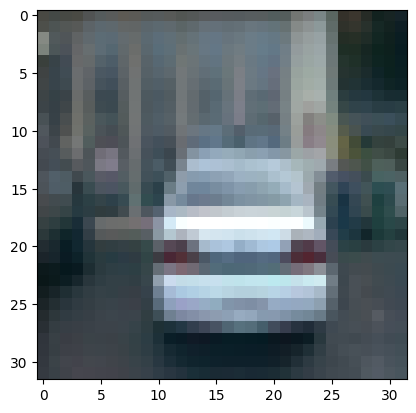

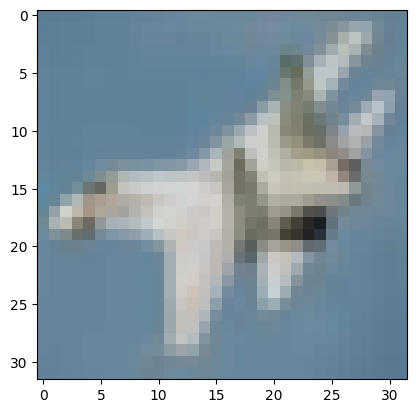

In [3]:
# Show some samples in the dataset
import matplotlib.pyplot as plt
imgplot = plt.imshow(X_train[5])
plt.show()
imgplot = plt.imshow(X_test[10])
plt.show()

## 2. Xây dựng mô hình

In [4]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, SpatialDropout2D, BatchNormalization, Dropout
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras import regularizers, optimizers
import numpy as np

#z-score
mean = np.mean(X_train,axis=(0,1,2,3))
std  = np.std(X_train,axis=(0,1,2,3))
X_train = (X_train-mean)/(std+1e-7)
X_val  = (X_val-mean)/(std+1e-7)
X_test  = (X_test-mean)/(std+1e-7)

weight_decay = 1e-5
initializer = tf.keras.initializers.he_normal()

# model
inputs = tf.keras.Input(shape=(32, 32, 3))
x = inputs

# block 1
previous = x
residual = Conv2D(64, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(previous)
residual = BatchNormalization()(residual)

x = Conv2D(64, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(64, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = keras.layers.Add()([x, residual]) 

x = MaxPooling2D(pool_size=(2,2))(x)
x = SpatialDropout2D(0.4)(x)


# block 2
previous = x
residual = Conv2D(128, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(previous)
residual = BatchNormalization()(residual)

x = Conv2D(128, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(128, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = keras.layers.Add()([x, residual]) 

x = MaxPooling2D(pool_size=(2,2))(x)
x = SpatialDropout2D(0.4)(x)


# block 3
previous = x
residual = Conv2D(256, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(previous)
residual = BatchNormalization()(residual)

x = Conv2D(256, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(256, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = Conv2D(256, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = keras.layers.Add()([x, residual]) 

x = MaxPooling2D(pool_size=(2,2))(x)
x = SpatialDropout2D(0.4)(x)

# block 4
x = Conv2D(512, (3,3), padding='same', activation='silu', 
           kernel_regularizer=regularizers.l1_l2(weight_decay, weight_decay), kernel_initializer=initializer)(x)
x = BatchNormalization()(x)

x = MaxPooling2D(pool_size=(2,2))(x)
x = SpatialDropout2D(0.4)(x)


# dense block 
x = Flatten()(x)
x = Dense(252, activation='silu', kernel_initializer=initializer)(x)
x = Dropout(0.4)(x)
outputs = keras.layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ add[0][0]         │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 16, 16,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │     73,856 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ batch_normalizat

 Total params: 3,999,070 (15.26 MB)

 Trainable params: 3,994,462 (15.24 MB)

 Non-trainable params: 4,608 (18.00 KB)

## 3. Cấu hình huấn luyện

In [5]:
#training info
batch_size = 512
epochs = 300
steps = X_train.shape[0] // batch_size

boundaries = [steps*75, steps*150, steps*200, steps*250]
values = [0.001, 0.0005, 0.0001, 0.00005, 0.00001]
schedules = keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values)
opt_adam  = keras.optimizers.AdamW(learning_rate=schedules, clipnorm=1.0)


# data augmentation
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_dataset  = tf.data.Dataset.from_tensor_slices((X_val, y_val))

def cutout(image, mask_size):
    image_shape = tf.shape(image)
    height, width = image_shape[0], image_shape[1]

    # Vị trí ngẫu nhiên để áp dụng mask
    cutout_center_height = tf.random.uniform(shape=[], minval=mask_size // 2, maxval=height - mask_size // 2, dtype=tf.int32)
    cutout_center_width = tf.random.uniform(shape=[], minval=mask_size // 2, maxval=width - mask_size // 2, dtype=tf.int32)

    # Tính toán vùng mask
    lower_pad = tf.maximum(0, cutout_center_height - mask_size // 2)
    upper_pad = tf.maximum(0, height - cutout_center_height - mask_size // 2)
    left_pad = tf.maximum(0, cutout_center_width - mask_size // 2)
    right_pad = tf.maximum(0, width - cutout_center_width - mask_size // 2)

    # Tạo mask với giá trị che phủ bằng 0
    mask = tf.pad(tensor=tf.zeros([mask_size, mask_size, 3], dtype=image.dtype),
                  paddings=[[lower_pad, upper_pad], [left_pad, right_pad], [0, 0]],
                  constant_values=1)
    
    return image * mask


def process_data(image, label):
    image = tf.cast(image, tf.float32)
    
    # Random resize and crop
    if tf.random.uniform(()) > 0.5:
        image = tf.image.resize(image, (38, 38))
        image = tf.image.random_crop(image, size=[32, 32, 3])
    
    # Random flip
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
    
    # Thay đổi độ tương phản
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, 0.8, 1.2)
    
    # Áp dụng Cutout ngẫu nhiên
    if tf.random.uniform(()) > 0.5:
        image = cutout(image, mask_size=10)  

    return image, label


train_batches = (train_dataset.shuffle(512*10)
                              .map(process_data, num_parallel_calls=tf.data.experimental.AUTOTUNE)
                              .batch(batch_size)
                              .prefetch(tf.data.experimental.AUTOTUNE) )

val_dataset = (val_dataset.batch(batch_size))


In [6]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=opt_adam, metrics=['accuracy'])

## 4. Huấn luyện mô hình

In [7]:
# Create a callback ModelCheckpoint. This callback will save the model when finding one better than the current best.
mc = keras.callbacks.ModelCheckpoint(filepath="best_model.keras", # Path to save the model
                                     monitor='val_loss', # Metric to evaluate the model performance when looking for a better model.
                                     mode='min', # mode='auto'/'max'/'min': the monitor should be max/min to be better. 
                                                 # In auto mode, the mode is set to max if the quantities monitored are 'acc' or start with 'fmeasure' (f-score) and are set to min for the rest of the quantities.
                                     verbose=1, # Inform every time a better model is found and saved.
                                     save_best_only=True) # Only save the model if the current training epoch is the best. 'False' means save models of all training epochs

# Train the model. Using Kaggle for training
history = model.fit(train_batches, validation_data=val_dataset, epochs=epochs, verbose=1, callbacks=[mc])

Epoch 1/300


I0000 00:00:1784199656.273970     103 service.cc:145] XLA service 0x7845540080d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784199656.274090     103 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1784199656.274097     103 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1784199685.024424     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.1900 - loss: 3.6452
Epoch 1: val_loss improved from inf to 2.71753, saving model to best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 93s 570ms/step - accuracy: 0.1906 - loss: 3.6400 - val_accuracy: 0.3686 - val_loss: 2.7175
Epoch 2/300
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.3444 - loss: 2.7770
Epoch 2: val_loss improved from 2.71753 to 2.43611, saving model to best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 211ms/step - accuracy: 0.3447 - loss: 2.7763 - val_accuracy: 0.4634 - val_loss: 2.4361
Epoch 3/300
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4157 - loss: 2.5637
Epoch 3: val_loss improved from 2.43611 to 2.28754, saving model to best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 216ms/step - accuracy: 0.4158 - loss: 2.5632 - val_accuracy: 0.4996 - val_loss: 2.2875
Epoch 4/300
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4667 - loss: 2.3933
Epoch 4: val_loss improved from 2.28754 to 2.10411, saving 

## 5. Đánh giá

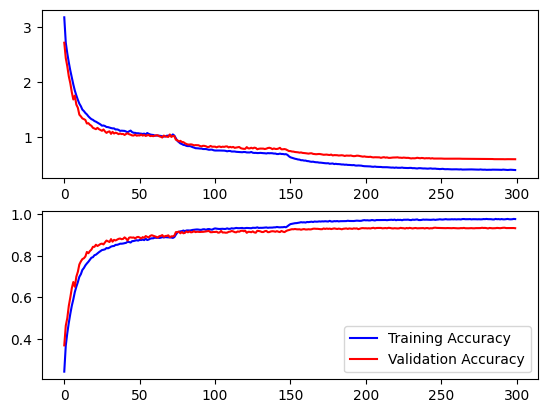

In [8]:
# Visualize training and validation performance
f,ax=plt.subplots(2,1) 

# Plot training and validation loss
ax[0].plot(history.history['loss'], color='b',label='Training Loss')
ax[0].plot(history.history['val_loss'],color='r',label='Validation Loss')

# Plot training and validation accuracy
ax[1].plot(history.history['accuracy'],color='b',label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'],color='r',label='Validation Accuracy')

plt.legend()

In [9]:
model = keras.models.load_model("best_model.keras")
result = model.evaluate(X_test, y_test) # If unspecified, batch_size will default to 32

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9372 - loss: 0.5942


In [10]:
# Show the model performance
print(model.metrics_names) # result[0] is loss, result[1] is accuracy. The metrics are defined in model.complie(...)
print("Loss and accuracy on the test set: loss = {}, accuracy = {}".format(result[0],result[1]))

['loss', 'compile_metrics']
Loss and accuracy on the test set: loss = 0.58929842710495, accuracy = 0.9383999705314636
